# 实验 ：MuJoCo Warp 入门 —— 用 CartPole 感受 GPU 并行仿真


1. **回顾 Gymnasium 里的 CartPole**：熟悉的 RL 环境接口
2. **换成更真实的物理引擎 MuJoCo**：同一个任务，物理更真实
3. **上 GPU 并行：MuJoCo Warp**：同一个模型，同时跑 1024 个环境，感受吞吐量

> **硬件要求**：**NVIDIA GPU + CUDA**

---
# 第 0 节：环境准备

| 库 | 用途 | 版本建议 |
|----|------|---------|
| `mujoco` | 物理引擎（CPU 版） | ≥ 3.2 |
| `mujoco-warp` | MuJoCo 的 GPU 加速版本 | 最新 |
| `warp-lang` | NVIDIA Warp 框架（Python → CUDA JIT） | ≥ 1.3 |
| `gymnasium` | RL 环境接口标准 | ≥ 0.29 |
| `Pillow` (PIL) | 生成 GIF 动图 | 任意 |
| `matplotlib` | 画图 | 任意 |
| `numpy` | 数值计算 | 任意 |

```bash
conda activate rl-course
pip install mujoco mujoco-warp warp-lang gymnasium Pillow matplotlib numpy notebook
```


In [1]:
import sys, platform
print(f"Python: {sys.version.split()[0]}  |  OS: {platform.system()} {platform.release()}")

import numpy as np
print(f"NumPy:  {np.__version__}")

import gymnasium as gym
print(f"Gymnasium: {gym.__version__}")

import mujoco
print(f"MuJoCo: {mujoco.__version__}")

import warp as wp
wp.init()
print(f"Warp:   {wp.__version__}")
print(f"可用设备: {wp.get_devices()}")

import mujoco_warp as mjwarp
print(f"mujoco_warp: OK")

assert any("cuda" in str(d) for d in wp.get_devices()), \
    "无 CUDA 设备！请检查显卡驱动或改用云端服务器"
print("环境自检通过")

Python: 3.11.15  |  OS: Windows 10
NumPy:  2.4.6
Gymnasium: 1.3.0
MuJoCo: 3.10.0
Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, CUDA driver not available (NVRTC compilation available)
   Devices:
     "cpu"      : "Intel64 Family 6 Model 170 Stepping 4, GenuineIntel"
   Kernel cache:
     \\?\C:\Users\32967\AppData\Local\NVIDIA\warp\Cache\1.14.0
Warp:   1.14.0
可用设备: ['cpu']
mujoco_warp: OK


AssertionError: 无 CUDA 设备！请检查显卡驱动或改用云端服务器

---
# 1. Gymnasium 里的 CartPole


In [2]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)
print(f"初始观测 obs = {obs}")
print(f"观测空间 obs_space = {env.observation_space}")
print(f"动作空间 act_space = {env.action_space}")

total_reward = 0
for step in range(200):
    action = env.action_space.sample()       # 随机动作
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        print(f"在第 {step} 步结束，累计奖励 = {total_reward}")
        break
env.close()

初始观测 obs = [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
观测空间 obs_space = Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
动作空间 act_space = Discrete(2)
在第 34 步结束，累计奖励 = 35.0


---
# 2. 更真实的物理引擎 —— MuJoCo 


## 2.1 MJCF(MuJoCo XML Format）：用 XML 描述一个 CartPole

下面这段 XML 描述了：

- 一个 `slider`（滑动关节）：小车可以沿 x 轴移动
- 一个 `hinge`（铰接关节）：杆子可以绕 y 轴转动
- 一个 `motor`（电机）：给 slider 关节施加连续力 ∈ [-10, 10]

In [3]:
CARTPOLE_XML = """
<mujoco model="cartpole">
  <option gravity="0 0 -9.81" timestep="0.01"/>

  <worldbody>
    <!-- 一根轨道 -->
    <geom name="floor" type="plane" size="3 0.5 0.1" rgba="0.8 0.9 0.8 1"/>

    <!-- 小车 -->
    <body name="cart" pos="0 0 0.1">
      <joint name="slider" type="slide" axis="1 0 0" range="-2.4 2.4"/>
      <geom type="box" size="0.2 0.15 0.1" mass="1" rgba="0.2 0.4 0.8 1"/>

      <!-- 杆子 -->
      <body name="pole" pos="0 0 0.1">
        <joint name="hinge" type="hinge" axis="0 1 0"/>
        <geom type="capsule" fromto="0 0 0 0 0 0.6" size="0.04" mass="0.1" rgba="0.9 0.3 0.3 1"/>
      </body>
    </body>
  </worldbody>

  <actuator>
    <!-- 一个电机作用在 slider 关节上 -->
    <motor name="push" joint="slider" ctrlrange="-10 10" gear="1"/>
  </actuator>
</mujoco>
"""

**关键概念**：

| 名字 | 含义 | 我们这里是什么 |
|------|------|--------------|
| **mjm(Model)** | **静态**数据：几何、质量、关节结构 | 由 XML 编译得到，仿真中不变 |
| **mjd(Data)** | **动态**状态：当前时刻的位置、速度、力 | 每一步都会更新 |
| **qpos** | 广义坐标（位置） | 长度 = nq |
| **qvel** | 广义速度 | 长度 = nv |
| **ctrl** | 控制输入（施加到 actuator 上） | 一个电机的推力 |  
  

> 💡 **对比 Gym**：Gym 的 `obs` 就是 `[qpos; qvel]` 拼起来 = 4 维，MuJoCo 分开存。

In [4]:
# 加载模型
mjm = mujoco.MjModel.from_xml_string(CARTPOLE_XML)
mjd = mujoco.MjData(mjm)


print(f"mjm.nq (广义坐标数) = {mjm.nq}   ← mjd.qpos：[小车位置, 杆角度]")
print(f"mjm.nv (广义速度数) = {mjm.nv}   ← mjd.qvel：[小车速度, 杆角速度]")
print(f"mjm.nu (控制输入数) = {mjm.nu}   ← mjd.ctrl一个电机")
print(f"物理步长 mjm.dt   = {mjm.opt.timestep} 秒")

mjm.nq (广义坐标数) = 2   ← mjd.qpos：[小车位置, 杆角度]
mjm.nv (广义速度数) = 2   ← mjd.qvel：[小车速度, 杆角速度]
mjm.nu (控制输入数) = 1   ← mjd.ctrl一个电机
物理步长 mjm.dt   = 0.01 秒


## 2.2 可视化

**代码解释**：

- `mujoco.mj_resetData(mjm, mjd)`：重置 `mjd` 到 `mjm` 定义的初始状态（相当于 `env.reset()`）。
- `mjd.qpos[1] = 0.15`：**手动修改初始状态** —— 把杆角度设为 0.15 弧度。
- `mjd.ctrl[0] = 0.0`：施力为0。
- `mujoco.mj_step(mjm, mjd)`：推进一个物理时间步（相当于 `env.step()`，但只做物理，不算 reward）。

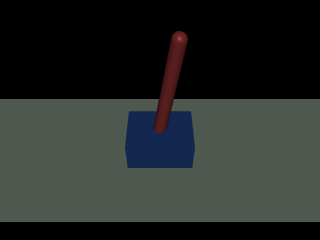

In [5]:
from PIL import Image
from IPython.display import Image as IPImage, display
import io

# 重置状态
mujoco.mj_resetData(mjm, mjd)
mjd.qpos[1] = 0.15   # 让杆稍微倾斜

# 渲染
renderer = mujoco.Renderer(mjm, height=240, width=320)

frames = []
for i in range(300):
    mjd.ctrl[0] = 0.0                # 不施加控制力，看杆自然倒下
    mujoco.mj_step(mjm, mjd)         # 推进一个物理步
    if i % 3 == 0:                   # 每 3 步存一帧，减小 GIF 体积
        renderer.update_scene(mjd)
        frames.append(Image.fromarray(renderer.render()))


buf = io.BytesIO()
frames[0].save(
    buf, format="GIF",
    save_all=True, append_images=frames[1:],
    duration=33,   # 每帧 33ms 
    loop=0         # 无限循环
)
display(IPImage(data=buf.getvalue()))
renderer.close()


# 3. 并行nworld

## nworld = 1

**代码解释**：

- `mjwarp.step(m, d)`：**GPU 版的推进一步**，语义和 `mujoco.mj_step` 完全一致，但作用在**所有** `nworld` 个世界上。
- `wp.synchronize()`：GPU 计算是**异步**的，`step` 返回时不代表算完了。用 `synchronize` 强制等 GPU 干完活，**测速度前一定要调**，否则测出来是假的。
- `d.qpos.numpy()`：把 GPU 上的数据**拷贝**回 CPU 内存变成 numpy，可以打印/画图。

In [6]:
# 复用之前的 mjm 和 mjd
# put_model: 把静态 model 编译并搬到 GPU
# put_data:  把动态 data 搬到 GPU，同时指定并行环境数 nworld

m = mjwarp.put_model(mjm)
d = mjwarp.put_data(mjm, mjd, nworld=1)   # 先只跑 1 个环境

print(f"CPU 版 qpos.shape = {mjd.qpos.shape}       ← 只是 (nq,)")
print(f"GPU 版 qpos.shape = {d.qpos.shape}         ← 多了一维 nworld！")
print(f"qpos 类型:  {type(d.qpos).__name__}        ← Warp array（在 GPU 上）")

CPU 版 qpos.shape = (2,)       ← 只是 (nq,)
GPU 版 qpos.shape = (1, 2)         ← 多了一维 nworld！
qpos 类型:  array        ← Warp array（在 GPU 上）


In [7]:
# 在 GPU 上跑 300 步仿真
import numpy as np

# 设置初始状态：杆倾斜 0.15 弧度
# Warp array ，不能像 numpy 那样 d.qpos[0, 1] = ... 直接赋值
# 要么整体替换，要么用 numpy() 拷贝出来改再赋回去
qpos_np = d.qpos.numpy()
qpos_np[0, 1] = 0.15
d.qpos = wp.array(qpos_np, dtype=wp.float32)

# 推进 300 步
for _ in range(300):
    mjwarp.step(m, d)
wp.synchronize()   # 等 GPU 算完

final_qpos = d.qpos.numpy()
print(f"\n\n300 步后：小车位置 = {final_qpos[0, 0]:+.3f} m, 杆角度 = {final_qpos[0, 1]:+.3f} rad ")

Module mujoco_warp._src.smooth 59177cd load on device 'cpu' took 10222.80 ms  (compiled)
Module _nxn_broadphase__locals__kernel_a09fd5ac 308e648 load on device 'cpu' took 1005.67 ms  (compiled)
Module _primitive_narrowphase__locals__primitive_narrowphase_f83f5f6b 89e868b load on device 'cpu' took 2048.27 ms  (compiled)
Module mujoco_warp._src.constraint 1055a87 load on device 'cpu' took 326.24 ms  (compiled)
Module _friction_dof__locals__kernel_7f5fef1d 85664fc load on device 'cpu' took 508.60 ms  (compiled)
Module _limit_slide_hinge__locals__kernel_2e45505b d92b065 load on device 'cpu' took 558.54 ms  (compiled)
Module _efc_contact_init__locals__kernel_0171803d 131b08d load on device 'cpu' took 411.43 ms  (compiled)
Module _efc_contact_jac_dense__locals__kernel_42cf4639 e770e43 load on device 'cpu' took 1685.61 ms  (compiled)
Module _efc_contact_update__locals__kernel_710e1642 a0d6216 load on device 'cpu' took 594.23 ms  (compiled)
Module mujoco_warp._src.forward 75facd5 load on devic

## nworld = 1024

**代码解释**：

- **warmup**：第一次调用 `step` 会编译 CUDA kernel，需先预热再测速，避免污染计时。
- **计时方式**：`t0 = time.time()` → 循环 → `wp.synchronize()` → `dt = time.time() - t0`。**必须** synchronize，否则测的只是"提交任务到 GPU 的时间"，不是"GPU 算完的时间"。
- **吞吐量单位 steps/sec**：单位时间内完成的**总步数**（所有 world 加起来）。

In [8]:
import time

nworld = 1024
d = mjwarp.put_data(mjm, mjd, nworld=nworld)

# 每个世界随机初始角度 ∈ [-0.2, 0.2]，模拟 RL 中的多样化初始条件
qpos_np = np.zeros((nworld, mjm.nq), dtype=np.float32)
qpos_np[:, 1] = np.random.uniform(-0.2, 0.2, size=nworld)
d.qpos = wp.array(qpos_np, dtype=wp.float32)

# 每个世界随机施加控制力
ctrl_np = np.random.uniform(-5, 5, size=(nworld, mjm.nu)).astype(np.float32)
d.ctrl = wp.array(ctrl_np, dtype=wp.float32)

# warmup: 先跑几步让 JIT 编译完成（不算进计时）
for _ in range(5):
    mjwarp.step(m, d)
wp.synchronize()

# 正式计时
t0 = time.time()
for _ in range(1000):
    mjwarp.step(m, d)
wp.synchronize()
dt = time.time() - t0

print(f"1024 个环境 × 1000 步  用时 {dt:.2f} 秒")
print(f"吞吐量 = {nworld * 1000 / dt:,.0f} steps/sec")

1024 个环境 × 1000 步  用时 47.99 秒
吞吐量 = 21,336 steps/sec


## 吞吐量曲线：不同 nworld 的对比

nworld =     1  用时  5.26s  吞吐量 =           95 steps/sec
nworld =     4  用时  5.85s  吞吐量 =          342 steps/sec
nworld =    16  用时  5.87s  吞吐量 =        1,364 steps/sec
nworld =    64  用时  7.04s  吞吐量 =        4,544 steps/sec
nworld =   256  用时  9.71s  吞吐量 =       13,188 steps/sec
nworld =  1024  用时 24.32s  吞吐量 =       21,052 steps/sec
nworld =  4096  用时 69.02s  吞吐量 =       29,672 steps/sec
nworld =  8192  用时 125.28s  吞吐量 =       32,695 steps/sec
nworld = 16384  用时 241.35s  吞吐量 =       33,943 steps/sec


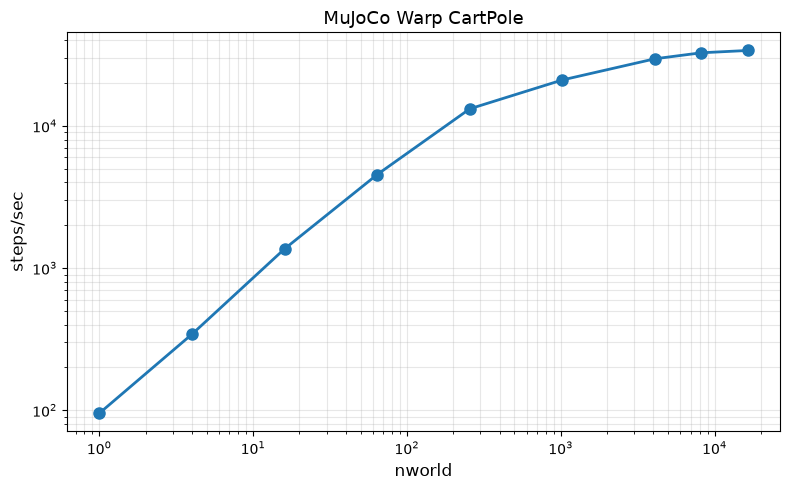

In [9]:
import matplotlib.pyplot as plt

# 不断增加 nworld 至瓶颈，观察吞吐量
nworlds = [1, 4, 16, 64, 256, 1024, 4096, 8192, 16384]
throughputs = []

for n in nworlds:
    d = mjwarp.put_data(mjm, mjd, nworld=n)
    # warmup
    for _ in range(5):
        mjwarp.step(m, d)
    wp.synchronize()
    # 计时
    t0 = time.time()
    for _ in range(500):
        mjwarp.step(m, d)
    wp.synchronize()
    dt = time.time() - t0
    tp = n * 500 / dt
    throughputs.append(tp)
    print(f"nworld = {n:5d}  用时 {dt:5.2f}s  吞吐量 = {tp:>12,.0f} steps/sec")

# 画图
plt.figure(figsize=(8, 5))
plt.loglog(nworlds, throughputs, "o-", linewidth=2, markersize=8)
plt.xlabel("nworld", fontsize=12)
plt.ylabel("steps/sec", fontsize=12)
plt.title("MuJoCo Warp CartPole", fontsize=13)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

##  测试

从 9 个不同初始角度出发。(nworld = 9)

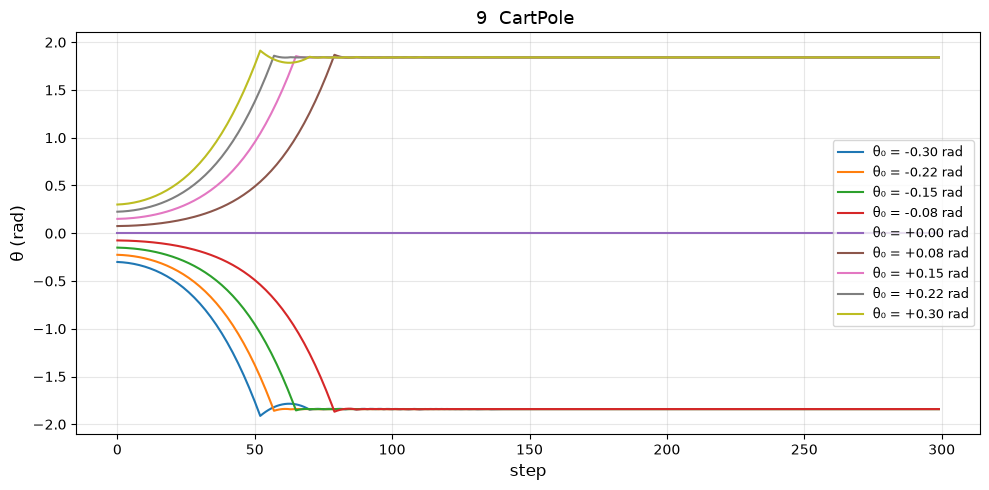

In [10]:
n_show = 9
n_step = 300
d = mjwarp.put_data(mjm, mjd, nworld=n_show)

# 给 9 个世界设置从 -0.3 到 +0.3 均匀分布的初始角度
init_thetas = np.linspace(-0.3, 0.3, n_show).astype(np.float32)
qpos_np = np.zeros((n_show, mjm.nq), dtype=np.float32)
qpos_np[:, 1] = init_thetas
d.qpos = wp.array(qpos_np, dtype=wp.float32)

# 记录每一步的杆角度
traj = np.zeros((n_step, n_show), dtype=np.float32)
for t in range(n_step):
    mjwarp.step(m, d)
    traj[t] = d.qpos.numpy()[:, 1]
wp.synchronize()

# 画图
plt.figure(figsize=(10, 5))
for i in range(n_show):
    plt.plot(traj[:, i], label=f"θ₀ = {init_thetas[i]:+.2f} rad")
plt.xlabel("step", fontsize=12)
plt.ylabel("θ (rad)", fontsize=12)
plt.title(f"{n_show}  CartPole ", fontsize=13)
plt.legend(fontsize=9, loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- 9 条曲线从不同初始角度出发，最终都因为重力倒向同一角度
- 初始角度越大，倒得越快

##


| 层次 | 工具 | 特点 |
|------|------|------|
| **RL 环境接口** | Gymnasium | 统一 API：`reset / step`，行业标准 |
| **物理引擎（CPU）** | MuJoCo | 真实物理，单环境，MJCF 描述模型 |
| **物理引擎（GPU）** | **MuJoCo Warp** | 同一个模型，`nworld` 个环境并行，为 RL 训练规模化 |


下一次实验

- **exp2**：Q-Learning 与 SARSA

🎉 **恭喜完成 exp1！** 